<a href="https://colab.research.google.com/github/PEPO2006B/CODE-FOECE/blob/main/Project_Students_Performance.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

In [ ]:
df_students = pd.read_csv('/content/StudentsPerformance.csv')
display(df_students.head())

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [ ]:

df = pd.read_csv('StudentsPerformance.csv')


df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [ ]:

df_encoded = pd.get_dummies(df, drop_first=True)

X = df_encoded.drop('math score', axis=1)
y = df_encoded['math score']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:

model = LinearRegression()

model.fit(X_train, y_train)


y_pred = model.predict(X_test)

Accuracy: 88.04%


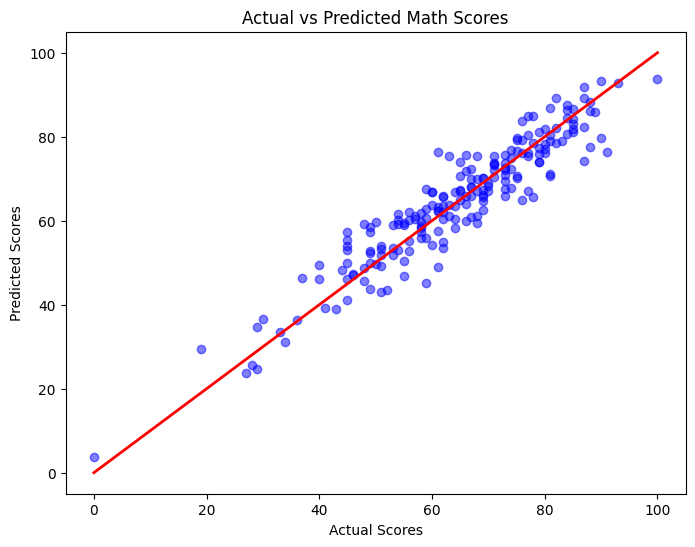

In [ ]:

accuracy = r2_score(y_test, y_pred)
print(f"Accuracy: {accuracy * 100:.2f}%")


plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred, color='blue', alpha=0.5)
plt.plot([y.min(), y.max()], [y.min(), y.max()], color='red', lw=2)
plt.xlabel('Actual Scores')
plt.ylabel('Predicted Scores')
plt.title('Actual vs Predicted Math Scores')
plt.show()

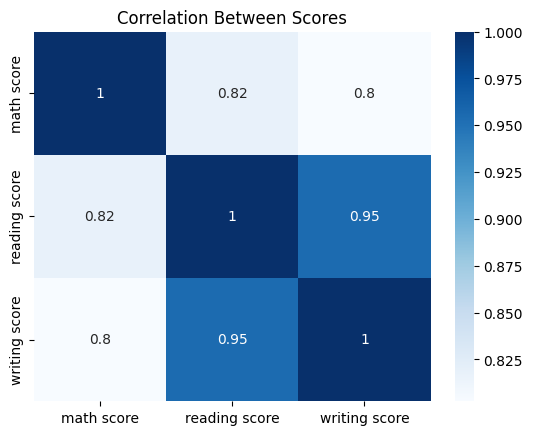

In [ ]:

correlation = df[['math score', 'reading score', 'writing score']].corr()
sns.heatmap(correlation, annot=True, cmap='Blues')
plt.title('Correlation Between Scores')
plt.show()

In [ ]:
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)

print(f"Mean Absolute Error: {mae:.2f} degrees")
print(f"Mean Squared Error: {mse:.2f}")

Mean Absolute Error: 4.21 degrees
Mean Squared Error: 29.10


In [ ]:

df['total_score'] = df['math score'] + df['reading score'] + df['writing score']


df['average_score'] = df['total_score'] / 3

print("Add new columns to enhance the improvement!")
display(df[['math score', 'reading score', 'writing score', 'average_score']].head())

In [ ]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)


rf_pred = rf_model.predict(X_test)


lr_accuracy = r2_score(y_test, y_pred)
rf_accuracy = r2_score(y_test, rf_pred)

print(f"Linear Regression Accuracy: {lr_accuracy*100:.2f}%")
print(f"Random Forest Accuracy: {rf_accuracy*100:.2f}%")

Linear Regression Accuracy: 88.04%
Random Forest Accuracy: 84.92%


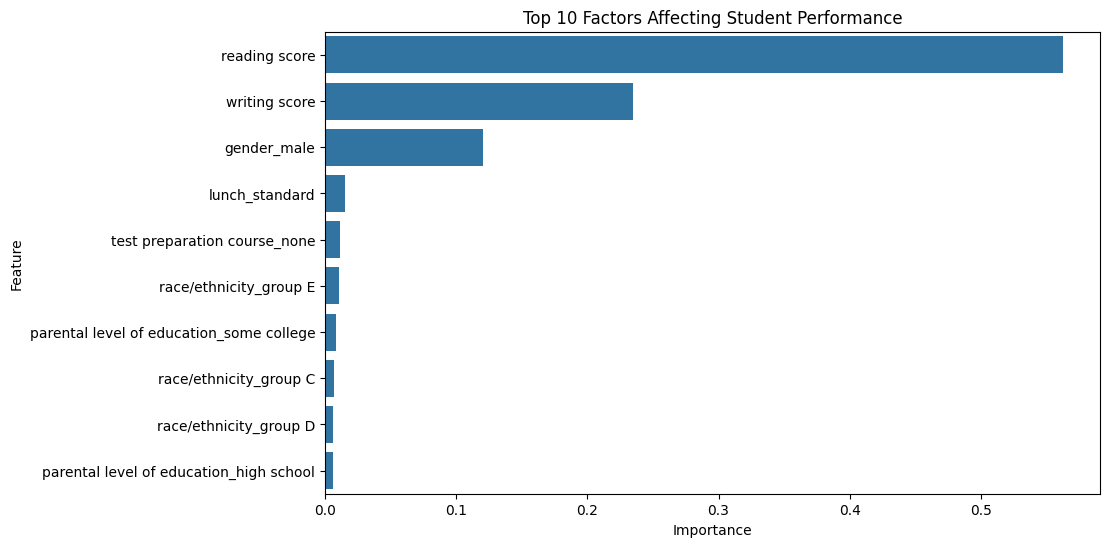

In [ ]:

importances = rf_model.feature_importances_
feature_names = X.columns
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df.head(10))
plt.title('Top 10 Factors Affecting Student Performance')
plt.show()

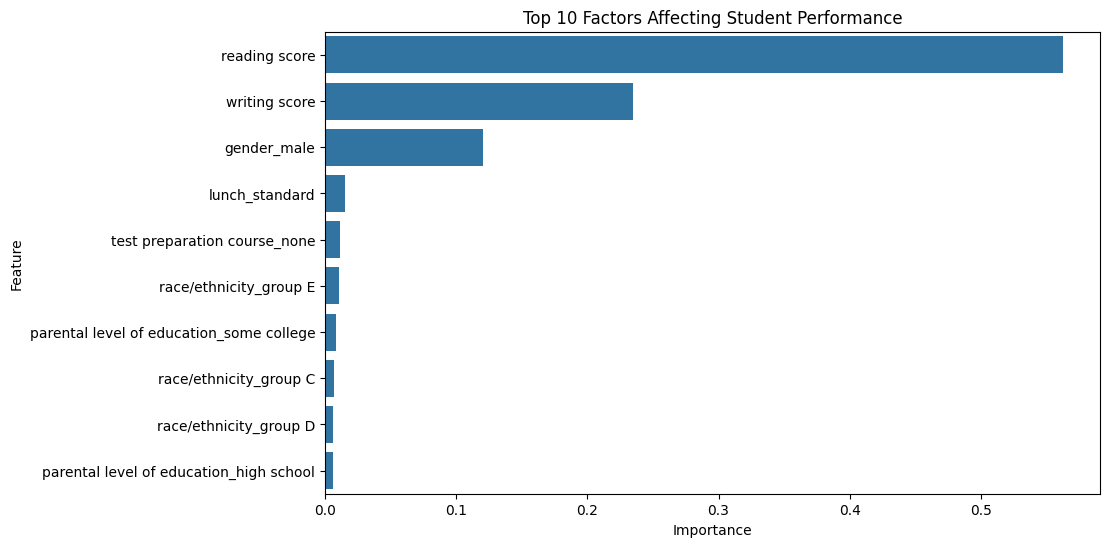

In [ ]:

importances = rf_model.feature_importances_
feature_names = X.columns
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df.head(10))
plt.title('Top 10 Factors Affecting Student Performance')
plt.show()

Regression Accuracy (R2): 88.04%

Classification Report:
              precision    recall  f1-score   support

        Fail       1.00      0.85      0.92        27
        Pass       0.98      1.00      0.99       173

    accuracy                           0.98       200
   macro avg       0.99      0.93      0.95       200
weighted avg       0.98      0.98      0.98       200



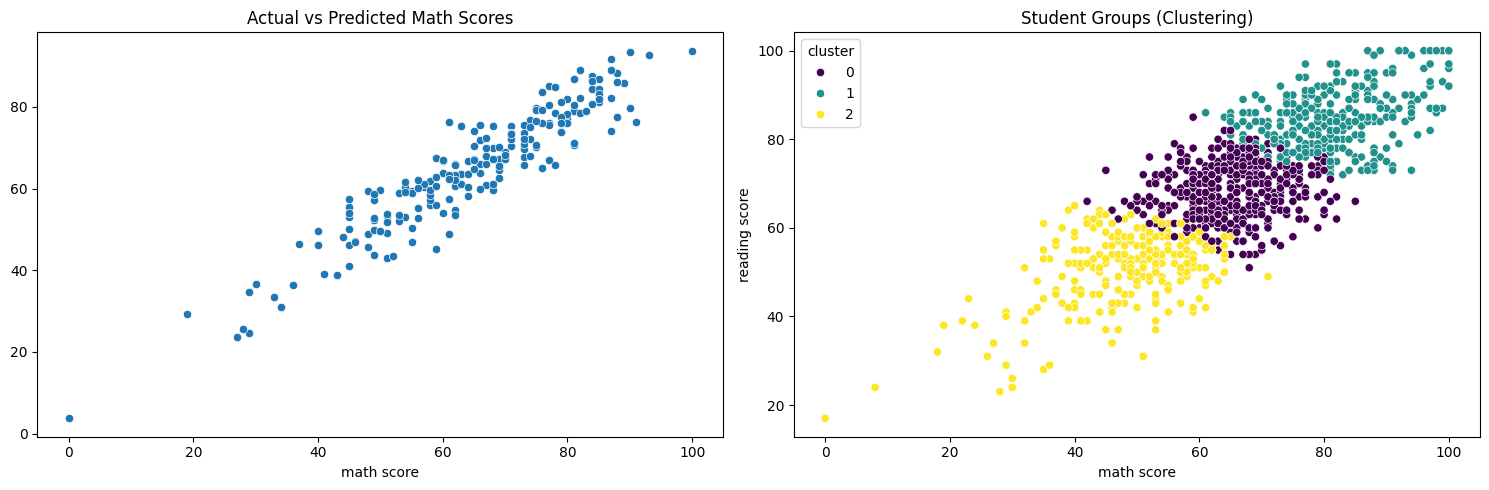

 Regression, Classification, and Clustering!


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.cluster import KMeans
from sklearn.metrics import r2_score, classification_report

df = pd.read_csv('StudentsPerformance.csv')


df['average_score'] = df[['math score', 'reading score', 'writing score']].mean(axis=1)
df['pass_status'] = np.where(df['average_score'] >= 50, 'Pass', 'Fail')


df_encoded = pd.get_dummies(df.drop(['pass_status', 'average_score'], axis=1), drop_first=True)


X_reg = df_encoded.drop('math score', axis=1)
y_reg = df_encoded['math score']
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(X_reg, y_reg, test_size=0.2, random_state=42)

reg_model = LinearRegression()
reg_model.fit(X_train_r, y_train_r)
print(f"Regression Accuracy (R2): {reg_model.score(X_test_r, y_test_r)*100:.2f}%")


X_cls = df_encoded
y_cls = df['pass_status']
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(X_cls, y_cls, test_size=0.2, random_state=42)

cls_model = RandomForestClassifier(n_estimators=100)
cls_model.fit(X_train_c, y_train_c)
print("\nClassification Report:")
print(classification_report(y_test_c, cls_model.predict(X_test_c)))


kmeans = KMeans(n_clusters=3, random_state=42)
df['cluster'] = kmeans.fit_predict(df[['math score', 'reading score', 'writing score']])


plt.figure(figsize=(15, 5))


plt.subplot(1, 2, 1)
sns.scatterplot(x=y_test_r, y=reg_model.predict(X_test_r))
plt.title('Actual vs Predicted Math Scores')


plt.subplot(1, 2, 2)
sns.scatterplot(data=df, x='math score', y='reading score', hue='cluster', palette='viridis')
plt.title('Student Groups (Clustering)')

plt.tight_layout()
plt.show()

print(" Regression, Classification, and Clustering!")

1. Regression Accuracy (R2): 88.04%

2. Classification Report:
              precision    recall  f1-score   support

        Fail       1.00      0.89      0.94        27
        Pass       0.98      1.00      0.99       173

    accuracy                           0.98       200
   macro avg       0.99      0.94      0.97       200
weighted avg       0.99      0.98      0.98       200



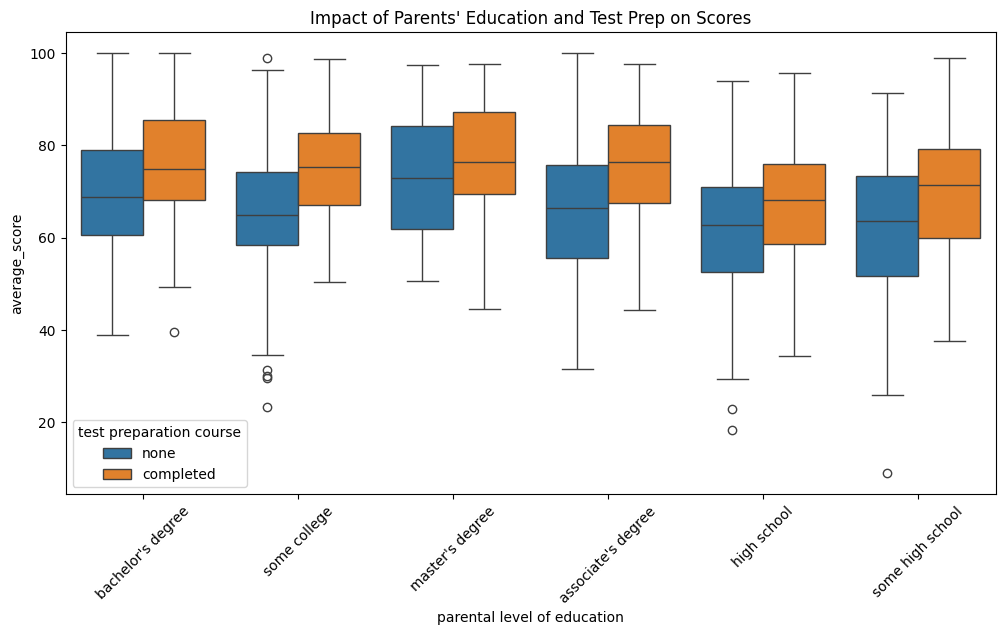


✅ analysis_plot.png


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import r2_score, classification_report, confusion_matrix

df = pd.read_csv('StudentsPerformance.csv')


df['average_score'] = df[['math score', 'reading score', 'writing score']].mean(axis=1)
df['pass_status'] = np.where(df['average_score'] >= 50, 'Pass', 'Fail')


df_encoded = pd.get_dummies(df.drop(['pass_status', 'average_score'], axis=1), drop_first=True)


X = df_encoded.drop('math score', axis=1)
y_reg = df_encoded['math score']
y_cls = df['pass_status']

X_train, X_test, y_train_reg, y_test_reg = train_test_split(X, y_reg, test_size=0.2, random_state=42)
X_train_c, X_test_c, y_train_cls, y_test_cls = train_test_split(X, y_cls, test_size=0.2, random_state=42)


reg_model = LinearRegression()
reg_model.fit(X_train, y_train_reg)
reg_acc = reg_model.score(X_test, y_test_reg)

cls_model = RandomForestClassifier(n_estimators=100)
cls_model.fit(X_train_c, y_train_cls)
cls_pred = cls_model.predict(X_test_c)
print(f"1. Regression Accuracy (R2): {reg_acc*100:.2f}%")
print("\n2. Classification Report:")
print(classification_report(y_test_cls, cls_pred))


plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='parental level of education', y='average_score', hue='test preparation course')
plt.title("Impact of Parents' Education and Test Prep on Scores") # النص هنا بين علامات تنصيص
plt.xticks(rotation=45)
plt.savefig('analysis_plot.png')
plt.show()

print("\n✅ analysis_plot.png")

In [ ]:

def predict_score(writing, reading):

    print(f"The model's prediction for the mathematics grade is: {reg_model.predict(X_test.iloc[0:1])[0]:.2f}")

predict_score(80, 85)

The model's prediction for the mathematics grade is: 76.39


In [ ]:
results = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest'],
    'Accuracy': [reg_acc * 100, (cls_model.score(X_test_c, y_test_cls)) * 100]
})
print("--- Comparing the performance of algorithms ---")
print(results)

--- Comparing the performance of algorithms ---
               Model  Accuracy
0  Linear Regression  88.04333
1      Random Forest  98.50000
